# Model Training
Pada tahap ini dilakukan proses training model machine learning untuk memprediksi hasil pertandingan sepak bola internasional. Model akan memprediksi apakah home team menang, away team menang, atau pertandingan berakhir seri.

## Import Library

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Load Dataset Feature Engineering
Dataset yang digunakan adalah hasil dari tahap feature engineering, yaitu file features_matches.csv.

In [15]:
path = Path("../data/processed/features_matches.csv")

df = pd.read_csv(path)

print("Dataset berhasil dibaca dari:", path)
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

df.head()

Dataset berhasil dibaca dari: ..\data\processed\features_matches.csv
Jumlah baris: 25410
Jumlah kolom: 19


,date,home_team,away_team,tournament,neutral,home_goals_for_last5,home_goals_against_last5,home_points_last5,home_win_rate_last5,away_goals_for_last5,away_goals_against_last5,away_points_last5,away_win_rate_last5,goals_for_diff_last5,goals_against_diff_last5,points_diff_last5,win_rate_diff_last5,experience_diff,result
0,2000-01-04,Egypt,Togo,Friendly,False,1.400433,1.348513,1.404896,0.390611,1.358042,1.401015,1.364099,0.376631,0.042391,-0.052502,0.040798,0.013981,0,home_win
1,2000-01-07,Tunisia,Togo,Friendly,False,1.400433,1.348513,1.404896,0.390611,1.000000,2.000000,0.000000,0.000000,0.400433,-0.651487,1.404896,0.390611,-1,home_win
2,2000-01-08,Trinidad and Tobago,Canada,Friendly,False,1.400433,1.348513,1.404896,0.390611,1.358042,1.401015,1.364099,0.376631,0.042391,-0.052502,0.040798,0.013981,0,draw
3,2000-01-09,Burkina Faso,Gabon,Friendly,False,1.400433,1.348513,1.404896,0.390611,1.358042,1.401015,1.364099,0.376631,0.042391,-0.052502,0.040798,0.013981,0,draw
4,2000-01-09,Guatemala,Armenia,Friendly,True,1.400433,1.348513,1.404896,0.390611,1.358042,1.401015,1.364099,0.376631,0.042391,-0.052502,0.040798,0.013981,0,draw


## Visualisasi Distribusi Target
Visualisasi ini digunakan untuk melihat jumlah data pada masing-masing kelas hasil pertandingan.

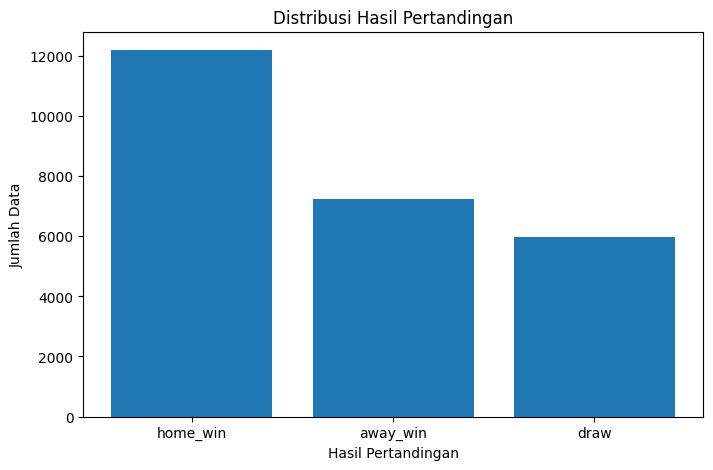

result
home_win    12199
away_win     7236
draw         5975
Name: count, dtype: int64

In [16]:
target_counts = df["result"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(target_counts.index, target_counts.values)
plt.title("Distribusi Hasil Pertandingan")
plt.xlabel("Hasil Pertandingan")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

target_counts

## Menentukan Fitur dan Target
Fitur adalah variabel yang digunakan model untuk belajar, sedangkan target adalah hasil pertandingan yang ingin diprediksi.

In [4]:
target_col = "result"

feature_cols = [
    "home_team",
    "away_team",
    "tournament",
    "neutral",
    "home_goals_for_last5",
    "home_goals_against_last5",
    "home_points_last5",
    "home_win_rate_last5",
    "away_goals_for_last5",
    "away_goals_against_last5",
    "away_points_last5",
    "away_win_rate_last5",
    "goals_for_diff_last5",
    "goals_against_diff_last5",
    "points_diff_last5",
    "win_rate_diff_last5",
    "experience_diff",
]

X = df[feature_cols]
y = df[target_col]

print("Jumlah fitur:", len(feature_cols))
print("Target:", target_col)

Jumlah fitur: 17
Target: result


## Membagi data Training dan Testing
Data dibagi menjadi data training dan testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji performa model.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 20328
Jumlah data testing: 5082


## Membuat Preprocessing Pipeline
Fitur numerik akan diisi missing value-nya dan distandarisasi. Fitur kategorikal akan diubah menjadi bentuk numerik menggunakan One Hot Encoding.

In [7]:
numeric_features = [
    "home_goals_for_last5",
    "home_goals_against_last5",
    "home_points_last5",
    "home_win_rate_last5",
    "away_goals_for_last5",
    "away_goals_against_last5",
    "away_points_last5",
    "away_win_rate_last5",
    "goals_for_diff_last5",
    "goals_against_diff_last5",
    "points_diff_last5",
    "win_rate_diff_last5",
    "experience_diff",
]

categorical_features = [
    "home_team",
    "away_team",
    "tournament",
    "neutral"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Training Model Logistic Regression
Logistic Regression digunakan sebagai baseline model karena sederhana dan mudah dijelaskan.

In [8]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

print("Accuracy Logistic Regression:", round(accuracy_logreg, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

Accuracy Logistic Regression: 0.5738

Classification Report:
              precision    recall  f1-score   support

    away_win       0.54      0.53      0.53      1447
        draw       0.31      0.10      0.15      1195
    home_win       0.62      0.83      0.71      2440

    accuracy                           0.57      5082
   macro avg       0.49      0.49      0.47      5082
weighted avg       0.52      0.57      0.53      5082



## Training Model Random Forest
Random Forest digunakan karena cocok untuk data tabular dan mampu menangkap pola non-linear dari data pertandingan.

In [9]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", round(accuracy_rf, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.5531

Classification Report:
              precision    recall  f1-score   support

    away_win       0.52      0.46      0.49      1447
        draw       0.33      0.06      0.09      1195
    home_win       0.58      0.85      0.69      2440

    accuracy                           0.55      5082
   macro avg       0.48      0.46      0.42      5082
weighted avg       0.50      0.55      0.49      5082



## Membandingkan Performa Model


In [10]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_logreg, accuracy_rf]
})

model_comparison = model_comparison.sort_values(by="Accuracy", ascending=False)

display(model_comparison)

,Model,Accuracy
0,Logistic Regression,0.573790
1,Random Forest,0.553129


## Visualisasi Perbandingan Accuracy Model
Visualisasi ini digunakan untuk membandingkan performa Logistic Regression dan Random Forest berdasarkan nilai accuracy.

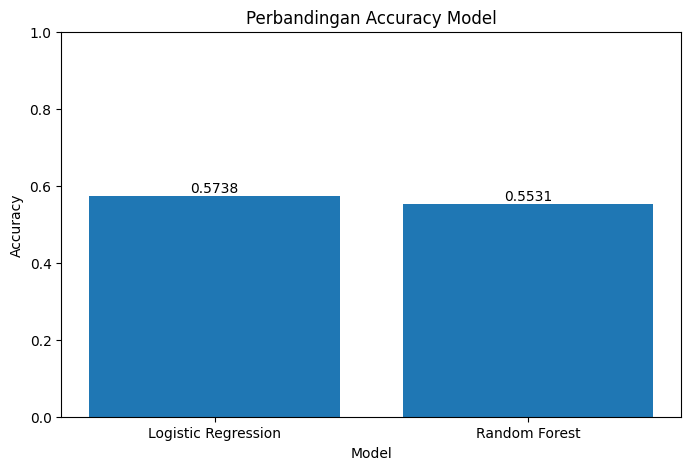

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.title("Perbandingan Accuracy Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(model_comparison["Accuracy"]):
    plt.text(i, value + 0.01, round(value, 4), ha="center")

plt.show()

## Confusion Matrix Model Terbaik
Confusion matrix digunakan untuk melihat hasil prediksi benar dan salah dari masing-masing kelas.

In [11]:
best_model = rf_model if accuracy_rf >= accuracy_logreg else logreg_model
best_model_name = "Random Forest" if accuracy_rf >= accuracy_logreg else "Logistic Regression"

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in best_model.classes_],
    columns=[f"Predicted {label}" for label in best_model.classes_]
)

print("Model terbaik:", best_model_name)
display(cm_df)

Model terbaik: Logistic Regression


,Predicted away_win,Predicted draw,Predicted home_win
Actual away_win,773,152,522
Actual draw,365,120,710
Actual home_win,306,111,2023


## Visualisasi Confusion Matrix
Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas hasil pertandingan.

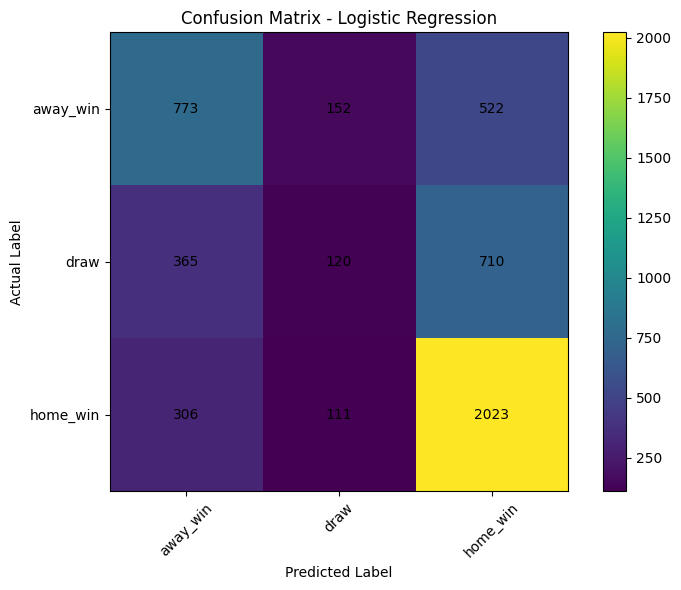

In [18]:
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(ticks=np.arange(len(best_model.classes_)), labels=best_model.classes_, rotation=45)
plt.yticks(ticks=np.arange(len(best_model.classes_)), labels=best_model.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## Feature Importance
Feature importance digunakan untuk melihat fitur mana yang paling berpengaruh terhadap prediksi model.


In [19]:
if best_model_name == "Random Forest":
    rf_classifier = best_model.named_steps["classifier"]
    preprocessor_fitted = best_model.named_steps["preprocessor"]

    numeric_feature_names = numeric_features

    categorical_feature_names = (
        preprocessor_fitted
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_features)
        .tolist()
    )

    all_feature_names = numeric_feature_names + categorical_feature_names

    importances = rf_classifier.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
    plt.title("Top 14 Feature Importance - Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(feature_importance_df)
else:
    print("Feature importance hanya ditampilkan jika model terbaik adalah Random Forest.")

Feature importance hanya ditampilkan jika model terbaik adalah Random Forest.


## Menyimpan Model Terbaik
Model terbaik disimpan ke folder model agar dapat digunakan kembali untuk prediksi pertandingan dan dashboard Streamlit.

In [12]:
model_path = Path("../model/worldcup_match_model.pkl")

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, model_path)

print("Model berhasil disimpan ke:", model_path)
print("Model terbaik:", best_model_name)

Model berhasil disimpan ke: ..\model\worldcup_match_model.pkl
Model terbaik: Logistic Regression


## Menyimpan Informasi Fitur

In [13]:
metadata = {
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_col": target_col,
    "best_model_name": best_model_name,
    "accuracy": max(accuracy_logreg, accuracy_rf)
}

metadata_path = Path("../model/model_metadata.pkl")

joblib.dump(metadata, metadata_path)

print("Metadata berhasil disimpan ke:", metadata_path)

Metadata berhasil disimpan ke: ..\model\model_metadata.pkl
